# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is linear as long as its coefficients are linear. Even if transformations like x^2 or log(x) are used, as long as the coefficients are linear, then the model is linear.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

The intercept is the baseline. The dummy coefficient tells you how much higher or lower that category is compared to the baseline.

3. Can linear regression be used for classification? Explain why, or why not.

Linear regression isn't constrained to [0,1], so it is not ideal although possible.

4. What are signs that your linear model is over-fitting?

High training performance but poor testing performance

5. Clearly explain multi-colinearity using the two-stage least squares technique.

When two predictors are highly correlated

In a two-stage perspective:

First, regress one correlated predictor on the others
Then use the residual in the main regression

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

As long as the coefficients of the model are linear, then the model is linear. You can use log transformation and polynomial terms.

7. What is the interpretation of the slope coefficient in a linear regression?

A change of one in the independent variable changes by whatever the slope is in the dependent variable.

8. Compare the train/test split and $k$-fold cross validation.

For train/test split, data is split into training and testing sets. Model is trained on training set and tested on testing set. For k-fold, data is split into k equal parts. Model is trained k times, each time leaving one fold for testing. Final performance is average of all sets. More reliable as it is less dependent on splits.

9. How is the $k$ in $k$-fold cross validation typically selected?

Low k has high bias but high k has high variation. It's good to have a good balance between.

In [2]:
! git clone https://github.com/derekwang8/undergrad_ml_assignments/

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 69 (delta 24), reused 10 (delta 10), pack-reused 36 (from 3)
Receiving objects: 100% (69/69), 11.63 MiB | 19.72 MiB/s, done.
Resolving deltas: 100% (28/28), done.


In [3]:
! python /content/undergrad_ml_assignments/get_data.py

Download complete
Extracting data files...
Data extracted


In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [5]:
df = pd.read_csv('/content/data/airbnb_hw.csv')

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [21]:
df.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating,log_price
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549.0,96.0,6.308098
5,1039,7/25/2008,Big Greenpoint 1BD w/ Skyline View,Brooklyn,Apartment,100.0,Entire home/apt,11222.0,1.0,1,4,149.0,100.0,5.003946
6,1783,8/12/2008,Amazing Also,Manhattan,Apartment,100.0,Entire home/apt,10004.0,1.0,1,9,250.0,100.0,5.521461
7,2078,8/15/2008,"Colorful, quiet, & near the subway!",Brooklyn,Apartment,90.0,Private room,11201.0,1.0,1,80,90.0,94.0,4.499810
8,2339,8/20/2008,East Village Cocoon: 2 Bedroom Flat,Manhattan,Apartment,90.0,Entire home/apt,10009.0,2.0,1,95,270.0,90.0,5.598422


In [7]:
print(df.columns)

Index(['Host Id', 'Host Since', 'Name', 'Neighbourhood ', 'Property Type',
       'Review Scores Rating (bin)', 'Room Type', 'Zipcode', 'Beds',
       'Number of Records', 'Number Of Reviews', 'Price',
       'Review Scores Rating'],
      dtype='object')


Average Price and Review Scores by Neighbourhood:
   Neighbourhood       Price  Review Scores Rating
0          Bronx   75.276498             91.654378
1       Brooklyn  127.747378             92.363497
2      Manhattan  183.659839             91.801785
3         Queens   96.857233             91.549057
4  Staten Island  146.166667             90.843750

Most expensive borough on average: Manhattan


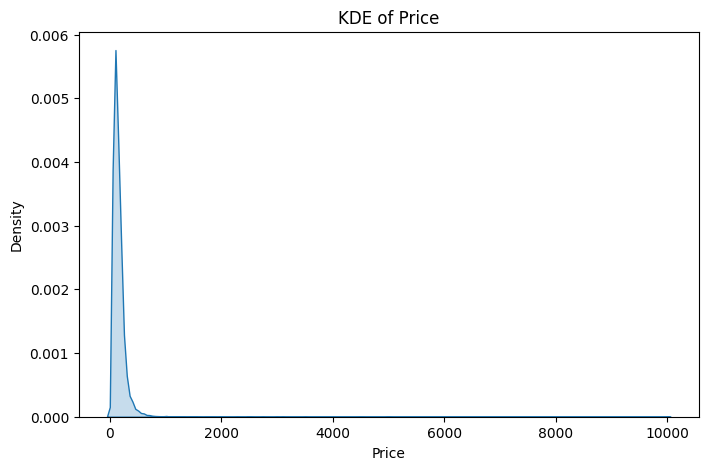

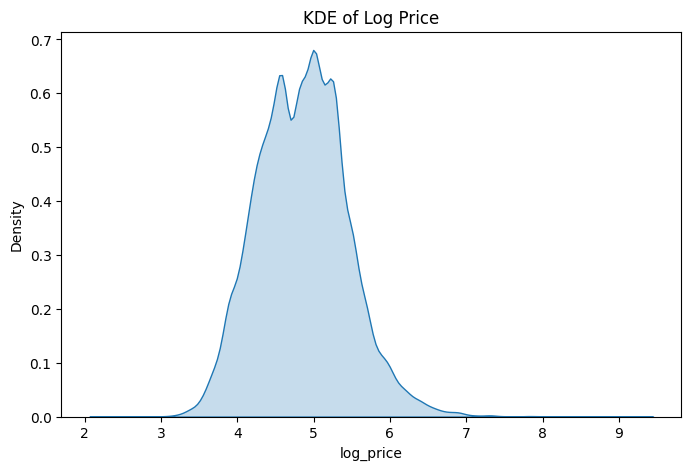

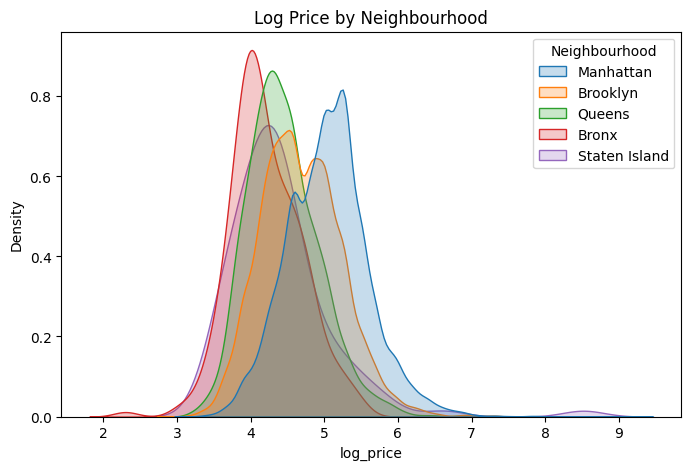


Regression: Price ~ Neighbourhood
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          4.37e-226
Time:                        06:24:32   Log-Likelihood:            -1.4175e+05
No. Observations:               22155   AIC:                         2.835e+05
Df Residuals:                   22150   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const      

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression

df = pd.read_csv('/content/data/airbnb_hw.csv')
df.columns = df.columns.str.strip()  # remove trailing spaces

price_col = 'Price'
neigh_col = 'Neighbourhood'
review_col = 'Review Scores Rating'

df = df.dropna(subset=[price_col, neigh_col, review_col])

df[price_col] = df[price_col].replace(r'[\$,]', '', regex=True)
df[price_col] = pd.to_numeric(df[price_col], errors='coerce')

df[review_col] = pd.to_numeric(df[review_col], errors='coerce')

df = df.dropna(subset=[price_col, review_col])

# 1.
grouped = df.groupby(neigh_col).agg({
    price_col: 'mean',
    review_col: 'mean'
}).reset_index()

print("Average Price and Review Scores by Neighbourhood:")
print(grouped)

# Most expensive borough
most_expensive = grouped.loc[grouped[price_col].idxmax(), neigh_col]
print(f"\nMost expensive borough on average: {most_expensive}")

# KDE of Price
plt.figure(figsize=(8,5))
sns.kdeplot(df[price_col], fill=True)
plt.title('KDE of Price')
plt.show()

# Log Price
df['log_price'] = np.log(df[price_col])
plt.figure(figsize=(8,5))
sns.kdeplot(df['log_price'], fill=True)
plt.title('KDE of Log Price')
plt.show()

# KDE by Neighbourhood (log price)
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='log_price', hue=neigh_col, common_norm=False, fill=True)
plt.title('Log Price by Neighbourhood')
plt.show()

# 2.

X_neigh = pd.get_dummies(df[neigh_col], drop_first=True).astype(float)
X_neigh = sm.add_constant(X_neigh)

y = df[price_col].astype(float)

model_neigh = sm.OLS(y, X_neigh).fit()
print("\nRegression: Price ~ Neighbourhood")
print(model_neigh.summary())

# Conditional group means vs coefficients:
# Intercept = baseline group mean
# Coefficients = difference from baseline

# 3.

X_review = sm.add_constant(df[review_col].astype(float))
model_review = sm.OLS(y, X_review).fit()
print("\nRegression: Price ~ Review Scores Rating")
print(model_review.summary())

# Interpretation: slope = expected change in price for 1-point increase in review score

# 4.

X_both = pd.get_dummies(df[neigh_col], drop_first=True).astype(float)
X_both[review_col] = df[review_col].astype(float)
X_both = sm.add_constant(X_both)

model_both = sm.OLS(y, X_both).fit()
print("\nRegression: Price ~ Neighbourhood + Review Scores Rating")
print(model_both.summary())

# Interpretation:
# - Slope on review scores may change compared to model 4
# - Neighborhood coefficients adjust for review scores

# 5.

dummies = pd.get_dummies(df[neigh_col], drop_first=False).astype(float)
interaction = dummies.mul(df[review_col], axis=0)
X_interaction = pd.concat([sm.add_constant(dummies), interaction], axis=1)

model_interaction = sm.OLS(y, X_interaction).fit()
print("\nRegression: Price ~ Constant + Neighborhood dummies + neighborhood-specific slopes for Review Scores")
print(model_interaction.summary())

# 6.

def cross_val_rmse(X, y, k=5):
    model = LinearRegression()
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    mse = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    rmse = np.sqrt(mse)
    return rmse.mean()

# Model 4 CV
X_cv4 = df[[review_col]].values
rmse4 = cross_val_rmse(X_cv4, y.values)
print(f"\nCV RMSE - Price ~ Review Scores Rating: {rmse4:.2f}")

# Model 5 CV
X_cv5 = X_both.drop(columns='const').values
rmse5 = cross_val_rmse(X_cv5, y.values)
print(f"CV RMSE - Price ~ Neighbourhood + Review Scores Rating: {rmse5:.2f}")

# Model 6 CV
X_cv6 = X_interaction.drop(columns='const').values
rmse6 = cross_val_rmse(X_cv6, y.values)
print(f"CV RMSE - Price ~ Neighborhood-specific slopes: {rmse6:.2f}")

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [55]:
df = pd.read_csv("/content/data/cars_hw.csv")
df.head()

df = df[["Price", "Seating_Capacity", "Body_Type", "Make_Year"]].copy()

df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Price             976 non-null    int64 
 1   Seating_Capacity  976 non-null    int64 
 2   Body_Type         976 non-null    object
 3   Make_Year         976 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 30.6+ KB


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


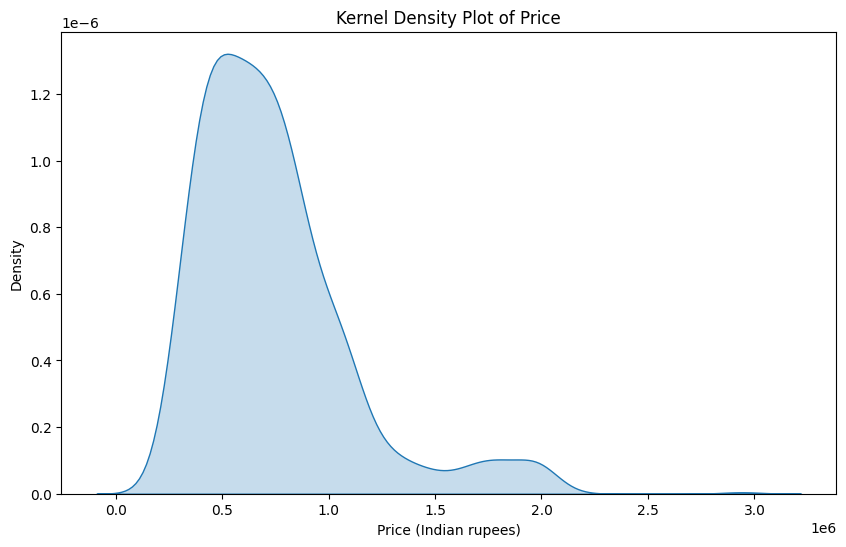

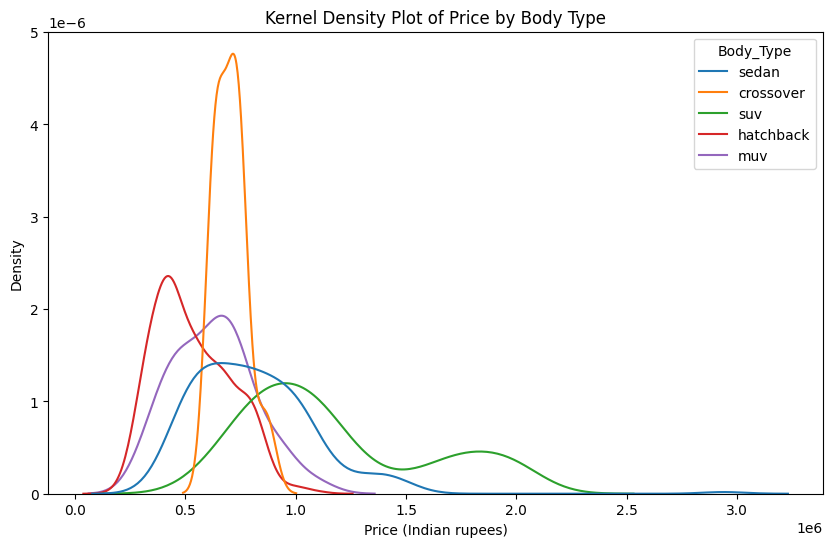

Average price by body type:
Body_Type
suv          1.176495e+06
sedan        8.097841e+05
crossover    7.050952e+05
muv          6.264211e+05
hatchback    5.339773e+05
Name: Price, dtype: float64

Standard deviation of price by body type:
Body_Type
suv          417479.028217
sedan        286736.770092
muv          184093.488526
hatchback    173086.729837
crossover     72849.780207
Name: Price, dtype: float64

Most expensive body type: suv
Body type with most variance: suv


In [57]:
# 1.
price_summary = df["Price"].describe()
print(price_summary)

plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x="Price", fill=True)
plt.title("Kernel Density Plot of Price")
plt.xlabel("Price (Indian rupees)")
plt.ylabel("Density")
plt.show()

body_price_summary = df.groupby("Body_Type")["Price"].describe()
body_price_summary

plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x="Price", hue="Body_Type", fill=False, common_norm=False)
plt.title("Kernel Density Plot of Price by Body Type")
plt.xlabel("Price (Indian rupees)")
plt.ylabel("Density")
plt.show()

mean_by_body = df.groupby("Body_Type")["Price"].mean().sort_values(ascending=False)
var_by_body = df.groupby("Body_Type")["Price"].var().sort_values(ascending=False)
std_by_body = df.groupby("Body_Type")["Price"].std().sort_values(ascending=False)

print("Average price by body type:")
print(mean_by_body)
print()

print("Standard deviation of price by body type:")
print(std_by_body)
print()

print("Most expensive body type:", mean_by_body.index[0])
print("Body type with most variance:", std_by_body.index[0])

In [60]:
#2.
model_seats_num = smf.ols("Price ~ Seating_Capacity", data=df).fit()
print(model_seats_num.summary())

slope = model_seats_num.params["Seating_Capacity"]
print(f"Slope coefficient: {slope:,.2f}")

# The slope coefficient tells us the estimated change in price for one additional seat. For this dataset, the slope is about 59,268 rupees, meaning that adding one seat is associated with an average increase of roughly ₹59,268 in price.

model_seats_cat = smf.ols("Price ~ C(Seating_Capacity)", data=df).fit()
print(model_seats_cat.summary())

seat_means = df.groupby("Seating_Capacity")["Price"].mean().sort_index()
seat_counts = df["Seating_Capacity"].value_counts().sort_index()

print("Mean price by seating capacity:")
print(seat_means)
print()
print("Counts by seating capacity:")
print(seat_counts)

# The differences in price are not roughly linear in the number of seats. But this should be interpreted cautiously because the data are highly unbalanced: most cars have 5 seats, while some seat counts appear only a few times.

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Wed, 25 Mar 2026   Prob (F-statistic):             0.0245
Time:                        07:49:35   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          4.39e+05   1.35e+05  

In [65]:
# 3.
df["Age"] = 2026 - df["Make_Year"]
df[["Make_Year", "Age"]].head()

X = df[["Age"]]
y = df["Price"]

kf = KFold(n_splits=10, shuffle=True, random_state=123)

cv_results = []

for degree in range(1, 11):
    pipeline = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("lm", LinearRegression())
    ])

    scores = cross_val_score(
        pipeline, X, y,
        cv=kf,
        scoring="neg_root_mean_squared_error"
    )

    rmse = -scores.mean()
    cv_results.append((degree, rmse))

cv_df = pd.DataFrame(cv_results, columns=["Degree", "CV_RMSE"])
cv_df

best_degree = cv_df.loc[cv_df["CV_RMSE"].idxmin(), "Degree"]
print("Best degree:", best_degree)

best_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=int(best_degree), include_bias=False)),
    ("lm", LinearRegression())
])

best_pipeline.fit(X, y)

Best degree: 7


Pipeline(steps=[('poly', PolynomialFeatures(degree=7, include_bias=False)),
                ('lm', LinearRegression())])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


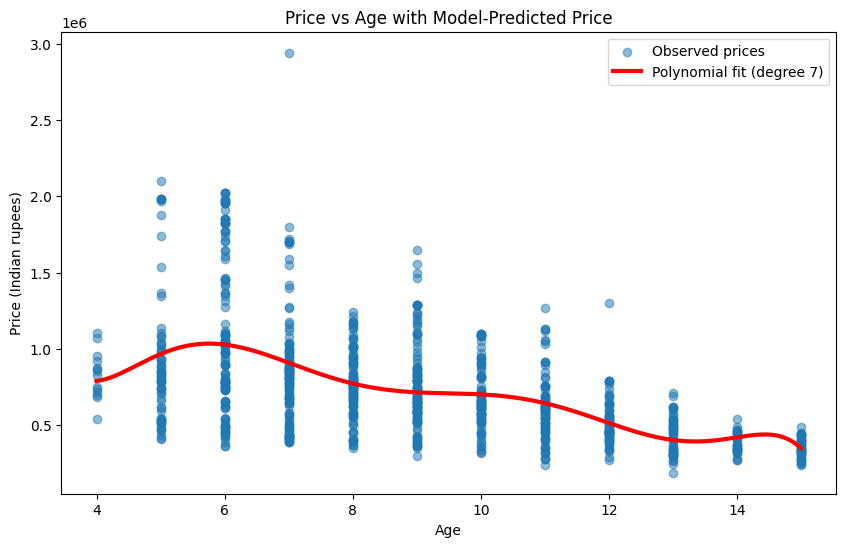

In [69]:
# 4.
age_grid = np.linspace(df["Age"].min(), df["Age"].max(), 300).reshape(-1, 1)
predicted_price = best_pipeline.predict(age_grid)

plt.figure(figsize=(10,6))
plt.scatter(df["Age"], df["Price"], alpha=0.5, label="Observed prices")
plt.plot(age_grid, predicted_price, color="red", linewidth=3, label=f"Polynomial fit (degree {int(best_degree)})")
plt.title("Price vs Age with Model-Predicted Price")
plt.xlabel("Age")
plt.ylabel("Price (Indian rupees)")
plt.legend()
plt.show()


**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [73]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
df = pd.read_csv("/content/data/heart_hw.csv")
df.head()

df = df[["y", "age", "transplant"]].copy()
df = df.dropna()

print(df.info())
print()
print("Unique transplant labels:", df["transplant"].unique())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   y           103 non-null    int64 
 1   age         103 non-null    int64 
 2   transplant  103 non-null    object
dtypes: int64(2), object(1)
memory usage: 2.5+ KB
None

Unique transplant labels: ['control' 'treatment']


,y,age,transplant
0,0,53,control
1,0,43,control
2,0,52,control
3,0,52,control
4,0,54,control


In [74]:
#1.
survival_by_group = df.groupby("transplant")["y"].mean()
print(survival_by_group)

a = survival_by_group["control"]
b = survival_by_group["treatment"]
ate = b - a

print(f"(a) Survival proportion in control group:   {a:.4f}")
print(f"(b) Survival proportion in treatment group: {b:.4f}")
print(f"ATE = (b) - (a): {ate:.4f}")


transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64
(a) Survival proportion in control group:   0.1176
(b) Survival proportion in treatment group: 0.3478
ATE = (b) - (a): 0.2302


In [75]:
#2.
model1 = smf.ols('y ~ C(transplant)', data=df).fit()
print(model1.summary())

print("Intercept:", model1.params["Intercept"])
print("Treatment coefficient:", model1.params["C(transplant)[T.treatment]"])

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Wed, 25 Mar 2026   Prob (F-statistic):             0.0133
Time:                        08:08:44   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000357
Time:                        08:13:47   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

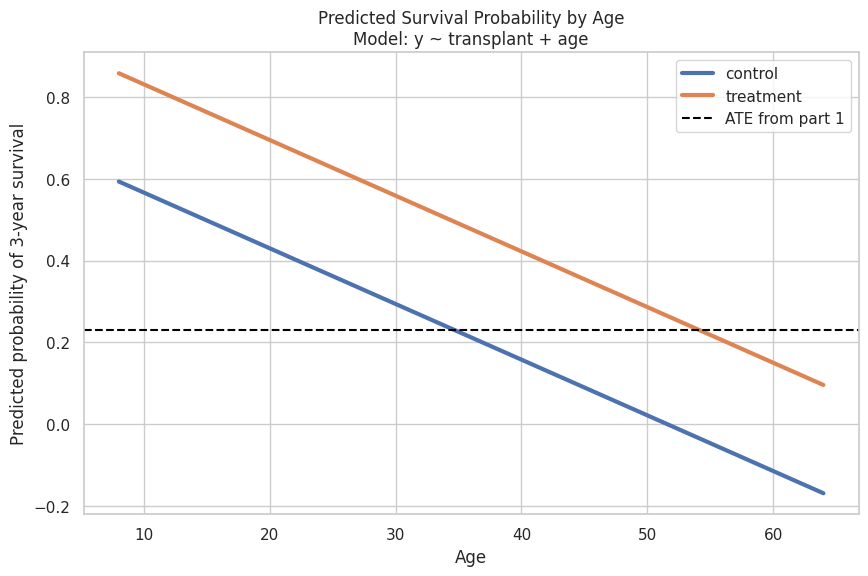

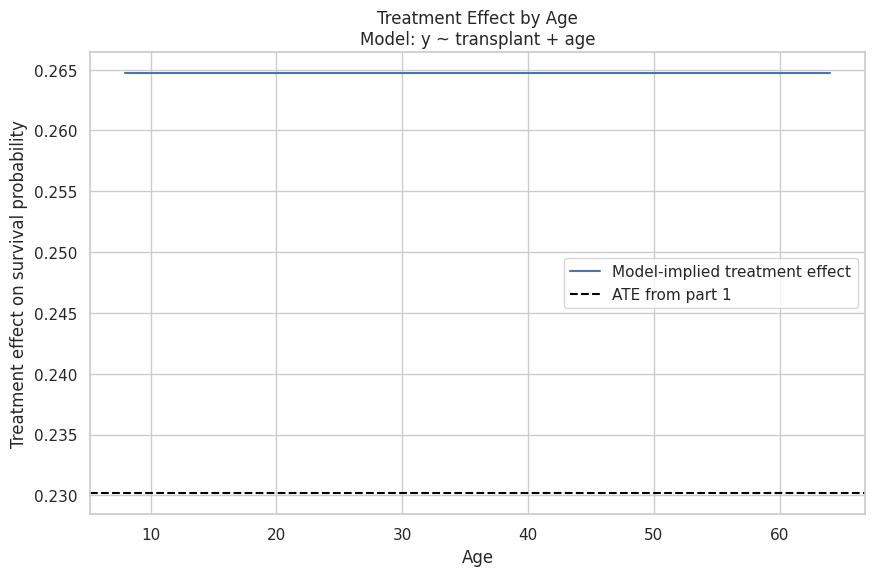

In [78]:
#3.
model2 = smf.ols('y ~ C(transplant) + age', data=df).fit()
print(model2.summary())

print("Intercept:", model2.params["Intercept"])
print("Treatment coefficient:", model2.params["C(transplant)[T.treatment]"])
print("Age coefficient:", model2.params["age"])

#The intercept is the predicted survival probability for a control-group patient with age 0, so it is usually not substantively meaningful here.
#The slope on age is the predicted change in survival probability for a one-year increase in age, holding transplant status fixed.
#The transplant coefficient is now the estimated treatment effect after controlling for age.

age_grid = np.linspace(df["age"].min(), df["age"].max(), 200)
plot_df = pd.DataFrame({
    "age": np.tile(age_grid, 2),
    "transplant": np.repeat(["control", "treatment"], len(age_grid))
})

plot_df["pred"] = model2.predict(plot_df)

plt.figure(figsize=(10,6))
sns.lineplot(data=plot_df, x="age", y="pred", hue="transplant", linewidth=3)
plt.axhline(ate, color="black", linestyle="--", label="ATE from part 1")
plt.title("Predicted Survival Probability by Age\nModel: y ~ transplant + age")
plt.xlabel("Age")
plt.ylabel("Predicted probability of 3-year survival")
plt.legend()
plt.show()

plot_wide = plot_df.pivot(index="age", columns="transplant", values="pred").reset_index()
plot_wide["treatment_effect_model2"] = plot_wide["treatment"] - plot_wide["control"]

plot_wide.head()

plt.figure(figsize=(10,6))
plt.plot(plot_wide["age"], plot_wide["treatment_effect_model2"], label="Model-implied treatment effect")
plt.axhline(ate, color="black", linestyle="--", label="ATE from part 1")
plt.title("Treatment Effect by Age\nModel: y ~ transplant + age")
plt.xlabel("Age")
plt.ylabel("Treatment effect on survival probability")
plt.legend()
plt.show()

#In the model without an interaction, the treatment effect does not vary by age, so the predicted treatment effect is constant across ages.
#If that constant effect differs from the raw ATE, it means age composition differs across treatment and control groups.
#In that case, the raw ATE may overstate or understate the transplant effect for all ages uniformly in this model

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000310
Time:                        08:18:20   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

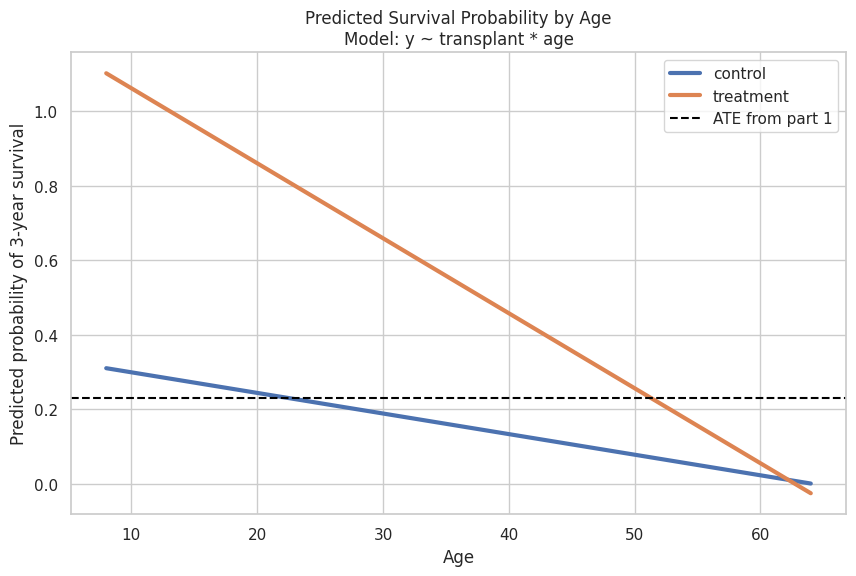

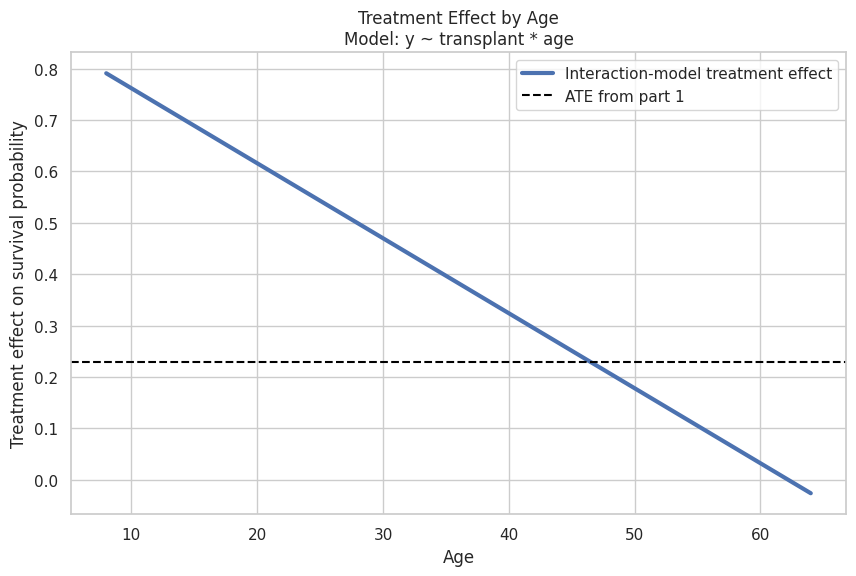

In [80]:
#4.
model3 = smf.ols('y ~ C(transplant) * age', data=df).fit()
print(model3.summary())

print(model3.params)

#The intercept is the predicted survival probability for control patients at age 0.
#The coefficient on age is the age slope for the control group.
#The coefficient on C(transplant)[T.treatment] is the transplant effect at age 0.
#The interaction coefficient shows how the transplant effect changes with age.

plot_df_int = pd.DataFrame({
    "age": np.tile(age_grid, 2),
    "transplant": np.repeat(["control", "treatment"], len(age_grid))
})

plot_df_int["pred"] = model3.predict(plot_df_int)

plt.figure(figsize=(10,6))
sns.lineplot(data=plot_df_int, x="age", y="pred", hue="transplant", linewidth=3)
plt.axhline(ate, color="black", linestyle="--", label="ATE from part 1")
plt.title("Predicted Survival Probability by Age\nModel: y ~ transplant * age")
plt.xlabel("Age")
plt.ylabel("Predicted probability of 3-year survival")
plt.legend()
plt.show()

plot_wide_int = plot_df_int.pivot(index="age", columns="transplant", values="pred").reset_index()
plot_wide_int["treatment_effect_model3"] = plot_wide_int["treatment"] - plot_wide_int["control"]

plt.figure(figsize=(10,6))
plt.plot(plot_wide_int["age"], plot_wide_int["treatment_effect_model3"], linewidth=3, label="Interaction-model treatment effect")
plt.axhline(ate, color="black", linestyle="--", label="ATE from part 1")
plt.title("Treatment Effect by Age\nModel: y ~ transplant * age")
plt.xlabel("Age")
plt.ylabel("Treatment effect on survival probability")
plt.legend()
plt.show()

#Allowing the interaction means the estimated effect of transplant can now change with age.
#If the treatment-effect line slopes upward or downward, the model is saying transplant is more beneficial for some ages than others.
#The key pattern to look for is whether the treatment and control prediction lines diverge or converge as age changes.

In [81]:
#5.
X = df[["transplant", "age"]]
y = df["y"]

preprocess_main = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), ["transplant"]),
    ("num", "passthrough", ["age"])
])

model_cv_2 = Pipeline([
    ("prep", preprocess_main),
    ("lm", LinearRegression())
])

kf = KFold(n_splits=10, shuffle=True, random_state=123)

rmse_model2 = -cross_val_score(
    model_cv_2, X, y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
).mean()

r2_model2 = cross_val_score(
    model_cv_2, X, y,
    cv=kf,
    scoring="r2"
).mean()

print("Model 2: y ~ transplant + age")
print("10-fold CV RMSE:", rmse_model2)
print("10-fold CV R^2:", r2_model2)

X3 = df[["transplant", "age"]].copy()

# Create manual interaction term after coding treatment as 0/1
X3["treat"] = (df["transplant"] == "treatment").astype(int)
X3["treat_age"] = X3["treat"] * X3["age"]

X3 = X3[["treat", "age", "treat_age"]]
y = df["y"]

model_cv_3 = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("lm", LinearRegression())
])

rmse_model3 = -cross_val_score(
    model_cv_3, X3, y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
).mean()

r2_model3 = cross_val_score(
    model_cv_3, X3, y,
    cv=kf,
    scoring="r2"
).mean()

print("Model 3: y ~ transplant * age")
print("10-fold CV RMSE:", rmse_model3)
print("10-fold CV R^2:", r2_model3)

# Model 1: y ~ transplant
X1 = df[["transplant"]]

preprocess_m1 = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), ["transplant"])
])

model_cv_1 = Pipeline([
    ("prep", preprocess_m1),
    ("lm", LinearRegression())
])

rmse_model1 = -cross_val_score(
    model_cv_1, X1, y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
).mean()

r2_model1 = cross_val_score(
    model_cv_1, X1, y,
    cv=kf,
    scoring="r2"
).mean()

cv_summary = pd.DataFrame({
    "Model": [
        "y ~ transplant",
        "y ~ transplant + age",
        "y ~ transplant * age"
    ],
    "CV_RMSE": [rmse_model1, rmse_model2, rmse_model3],
    "CV_R2": [r2_model1, r2_model2, r2_model3]
})

cv_summary


Model 2: y ~ transplant + age
10-fold CV RMSE: 0.41869620293965176
10-fold CV R^2: -0.007683439394165414
Model 3: y ~ transplant * age
10-fold CV RMSE: 0.4192707313084171
10-fold CV R^2: -0.05696188358649035


,Model,CV_RMSE,CV_R2
0,y ~ transplant,0.435525,-0.059498
1,y ~ transplant + age,0.418696,-0.007683
2,y ~ transplant * age,0.419271,-0.056962


In [83]:
#6.

#Selection bias: patients who receive transplants are not randomly assigned, so treatment and control groups may differ in health in ways not captured by age.
#Omitted variables: survival likely depends on many factors besides age and transplant status, such as disease severity, comorbidities, and access to follow-up care
#Linear probability model limitations: predicted probabilities can fall below 0 or above 1, and effects are forced into a simple linear structure.
#Fairness concerns: using a model to prioritize transplant access could disadvantage certain age groups or patient populations if the model reflects historical inequities.
#Feedback loops: if the model influences who gets treatment, future data will be shaped by the model's own decisions.
#Clinical risk: prediction alone should not determine transplant access because high-stakes medical decisions require physician judgment and ethical oversight.

